# BHNS GRB Classes and Formation Channels

**Hypothesis:** The Foucart et al. (2018) BHNS GRB sub-types (Short cbGRB and Long cbGRB, classified by disk mass) are overwhelmingly produced by the Classic CE (Channel I) formation pathway, following the framework of Broekgaarden et al. ([2021, Paper I](https://arxiv.org/abs/2103.02608); [2022, Paper II](https://arxiv.org/abs/2112.05763)).

**Physical motivation:**
- **Classic CE** (Channel I): The BH progenitor (more massive star) is stripped by stable RLOF and undergoes core-collapse SN to form the BH. The NS progenitor later undergoes CE with the BH and then a SN (often ultra-stripped) to form the NS. This channel dominates BHNS formation (~86% in Broekgaarden et al. 2021, Paper I).
- **Double-core CE** (Channel IV): Both stars undergo CE simultaneously while both have a core-envelope structure. This requires near-equal initial masses ($q_i \sim 0.9$-$1.0$), which rarely produces a BH+NS pair. Negligible for BHNS (~1%).
- In stark contrast to BNS (where Double-core CE dominates at ~60-70% detection-weighted), BHNS formation is overwhelmingly dominated by Classic CE. This asymmetry is a key prediction of isolated binary evolution.

**Connection to BNS:** The companion analysis in `GRB_BNS_FormationChannels.ipynb` shows that Long cbGRBs from BNS preferentially come from Classic CE (which produces asymmetric NS masses). Here we test whether the same Classic CE channel also dominates all BHNS GRB production, completing the unified evolutionary picture.

**Scenario note:** GRB classes are defined by Foucart disk mass thresholds following Gottlieb et al. (2023): No GRB ($M_{\rm disk} < 0.01\,M_\odot$), Short cbGRB ($0.01 \leq M_{\rm disk} < 0.1\,M_\odot$), Long cbGRB ($M_{\rm disk} \geq 0.1\,M_\odot$). See `GRB_BHNS.ipynb` for the full classification details.

**Data:** COMPAS Model A fiducial BHNS: [Zenodo 5178777](https://zenodo.org/records/5178777)

## 1. Imports & Data Loading

In [1]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d

path = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5'

with h5.File(path, 'r') as f:
    fDCO = f['doubleCompactObjects']

    mass1              = fDCO['M1'][...].squeeze()
    mass2              = fDCO['M2'][...].squeeze()
    weights            = fDCO['weight'][...].squeeze()
    metallicitySystems = fDCO['Metallicity1'][...].squeeze()
    mergesInHubbleTime = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc                 = fDCO['tc'][...].squeeze()
    tform              = fDCO['tform'][...].squeeze()
    m1zams             = fDCO['M1ZAMS'][...].squeeze()
    m2zams             = fDCO['M2ZAMS'][...].squeeze()
    stype1             = fDCO['stellarType1'][...].squeeze()

    dblCEflag          = fDCO['doubleCommonEnvelopeFlag'][...].squeeze()
    mtCase1            = fDCO['PrimaryMTCase'][...].squeeze()
    sep_preCE          = fDCO['SemiMajorAxisPreCEE'][...].squeeze()

    print(f'=== HDF5 top-level groups ===')
    print(list(f.keys()))
    print()

    fc = f['formationChannels']
    print(f'=== formationChannels keys ({len(fc.keys())}) ===')
    print(list(fc.keys()))

print(f"\nTotal BHNS systems: {len(mass1):,}")

=== HDF5 top-level groups ===
['RLOF', 'commonEnvelopes', 'doubleCompactObjects', 'formationChannels', 'supernovae', 'systems', 'weights_detected', 'weights_detectedPerRedshift', 'weights_intrinsic', 'weights_intrinsicPerRedshift']

=== formationChannels keys (36) ===
['CEE', 'CEE_failed', 'CEE_failed_instigator', 'CEE_instigator', 'CEE_wet', 'CEE_wet_instigator', 'SN_primary_type_1', 'SN_primary_type_2', 'SN_primary_type_3', 'SN_secondary_type_1', 'SN_secondary_type_2', 'SN_secondary_type_3', 'binary_disbound', 'eventCounter', 'm_randomSeed', 'merged_in_Hubble_time', 'mt_primary_ep1', 'mt_primary_ep1_K1', 'mt_primary_ep1_K2', 'mt_primary_ep2', 'mt_primary_ep2_K1', 'mt_primary_ep2_K2', 'mt_primary_ep3', 'mt_primary_ep3_K1', 'mt_primary_ep3_K2', 'mt_secondary_ep1', 'mt_secondary_ep1_K1', 'mt_secondary_ep1_K2', 'mt_secondary_ep2', 'mt_secondary_ep2_K1', 'mt_secondary_ep2_K2', 'mt_secondary_ep3', 'mt_secondary_ep3_K1', 'mt_secondary_ep3_K2', 'stellar_type_K1', 'stellar_type_K2']

Total BH

## 2. BHNS GRB Classification (Foucart Disk Mass)

Classification uses the Foucart et al. (2018) Eq. (4) & (6) disk mass formula with mass-dependent NS radius ($R_{1.4} = 12\,$km) and baryon mass correction $M^b \approx M_g + 0.080\,M_g^2$ (Gao et al. 2020), matching `GRB_BHNS.ipynb`.

BH spin is the dominant BHNS uncertainty. We classify at **two fiducial spins**:
- $a = 0.5$ (fiducial): No Long cbGRBs expected; only Short + No GRB classes.
- $a = 0.9$ (high-spin): Long cbGRBs appear; enables cross-tabulation of all three GRB classes with formation channels.

**Disk mass thresholds:** No GRB ($M_{\rm disk} < 0.01\,M_\odot$), Short cbGRB ($0.01 \leq M_{\rm disk} < 0.1\,M_\odot$), Long cbGRB ($M_{\rm disk} \geq 0.1\,M_\odot$).

In [2]:
def r_isco(a_BH):
    """ISCO radius in units of G*M_BH/c^2 (Bardeen et al. 1972)."""
    Z1 = 1 + (1 - a_BH**2)**(1/3) * ((1 + a_BH)**(1/3) + (1 - a_BH)**(1/3))
    Z2 = np.sqrt(3*a_BH**2 + Z1**2)
    sign = np.where(a_BH >= 0, 1.0, -1.0)
    return 3 + Z2 - sign * np.sqrt((3 - Z1)*(3 + Z1 + 2*Z2))

def ns_baryon_mass(M_NS):
    """M^b ~ M_g + 0.080 * M_g^2 (Gao et al. 2020)."""
    return M_NS + 0.080 * M_NS**2

def ns_radius(M_NS, R_1p4_km=12.0):
    """Mass-dependent NS radius [km]. R_{1.4} = 12.0 km (NICER)."""
    return R_1p4_km * np.maximum(0.75, 1.0 - 0.25 * (M_NS - 1.4)**2)

def remnant_to_disk(M_rem, f_disk_constant=None):
    """Sigmoid remnant-to-disk conversion (Foucart 2012 Sec. VI)."""
    if f_disk_constant is not None:
        return f_disk_constant * M_rem
    f = 0.3 + 0.2 / (1.0 + np.exp(-(M_rem - 0.1) / 0.02))
    return f * M_rem

def foucart_disk_mass(M_BH, M_NS, a_BH=0.0, R_1p4_km=12.0, f_disk_constant=None):
    """Foucart et al. (2018) Eq. (4) & (6) [arXiv:1807.00011].
    Uses mass-dependent NS radius and quadratic baryon mass, matching GRB_BHNS.ipynb."""
    G = 6.674e-11; c = 3e8; Msun = 1.989e30
    R_km = ns_radius(M_NS, R_1p4_km=R_1p4_km)
    C_NS  = G * M_NS * Msun / (R_km * 1e3 * c**2)
    eta   = M_NS * M_BH / (M_NS + M_BH)**2
    R_hat = r_isco(a_BH)
    alpha, beta, gamma, delta = 0.406, 0.139, 0.255, 1.761
    bracket = alpha * (1 - 2*C_NS) / eta**(1/3) - beta * R_hat * C_NS / eta + gamma
    M_b = ns_baryon_mass(M_NS)
    M_rem = np.maximum(0.0, bracket)**delta * M_b
    return remnant_to_disk(M_rem, f_disk_constant=f_disk_constant)

mask_merging = (mergesInHubbleTime == 1)
is_BH1 = (stype1[mask_merging] == 14)

M_BH = np.where(is_BH1, mass1[mask_merging], mass2[mask_merging])
M_NS = np.where(is_BH1, mass2[mask_merging], mass1[mask_merging])

w_m      = weights[mask_merging]
Z_m      = metallicitySystems[mask_merging]
delay_m  = (tform + tc)[mask_merging]
m1z_m    = m1zams[mask_merging]
m2z_m    = m2zams[mask_merging]
dblCE_m  = dblCEflag[mask_merging]
mtC1_m   = mtCase1[mask_merging]
sep_pre  = sep_preCE[mask_merging]

n_merging = mask_merging.sum()
Q = M_BH / M_NS

grb_classes = {}
for a_spin in [0.5, 0.9]:
    M_disk = foucart_disk_mass(M_BH, M_NS, a_BH=a_spin)
    no_grb    = (M_disk < 0.01)
    short_grb = (M_disk >= 0.01) & (M_disk < 0.1)
    long_grb  = (M_disk >= 0.1)
    grb_classes[a_spin] = {'No GRB': no_grb, 'Short cbGRB': short_grb, 'Long cbGRB': long_grb}

    total_w = w_m.sum()
    print(f"\n=== a_BH = {a_spin} ===")
    print(f"Merging BHNS: {n_merging:,}  (BH-primary: {is_BH1.sum():,})")
    for name, mask in [('No GRB', no_grb), ('Short cbGRB', short_grb), ('Long cbGRB', long_grb)]:
        n = mask.sum()
        wpct = 100 * w_m[mask].sum() / total_w
        print(f"  {name:<15s}  {n:>8,d}  ({wpct:5.1f}%)")


=== a_BH = 0.5 ===
Merging BHNS: 1,525,553  (BH-primary: 1,514,082)
  No GRB           1,481,831  ( 90.0%)
  Short cbGRB        43,722  ( 10.0%)
  Long cbGRB              0  (  0.0%)

=== a_BH = 0.9 ===
Merging BHNS: 1,525,553  (BH-primary: 1,514,082)
  No GRB            894,165  ( 46.2%)
  Short cbGRB       393,716  ( 28.6%)
  Long cbGRB        237,672  ( 25.3%)


## 3. Formation Channel Classification

Classify merging BHNS into formation channels following Broekgaarden et al. ([2021](https://arxiv.org/abs/2103.02608); [2022](https://arxiv.org/abs/2112.05763)).

For BHNS, the physical picture differs from BNS:
- **Channel I (Classic CE):** The BH progenitor (initially more massive) transfers mass stably, then undergoes core-collapse SN to form the BH. The NS progenitor later fills its Roche lobe, triggering a CE with the BH, followed by an ultra-stripped SN to form the NS. This is expected to dominate BHNS (~86%).
- **Channel IV (Double-core CE):** Both stars undergo CE while both have core-envelope structure. Requires near-equal initial masses, which rarely produces a BH+NS pair. Expected to be negligible (~1%).
- **Channel II (Stable MT only):** No CE event occurs.
- **Channel III (Single-core CE first):** First MT is an unstable CE, secondary is still a MS star.
- **Channel V (Other):** Everything else.

**Note:** The Channel III identification using `PrimaryMTCase == 0` assumes this value means "no prior stable mass transfer occurred." This interpretation should be verified against COMPAS column definitions.

In [3]:
had_CE = (sep_pre > 0)

ch_IV    = (dblCE_m == 1)
ch_II    = ~had_CE & ~ch_IV
ch_III   = had_CE & ~ch_IV & (mtC1_m == 0)
ch_I     = had_CE & ~ch_IV & ~ch_III
ch_other = ~(ch_I | ch_II | ch_III | ch_IV)

channel_masks = {
    'I  Classic CE':      ch_I,
    'II  Stable MT only': ch_II,
    'III Single-core CE': ch_III,
    'IV  Double-core CE': ch_IV,
    'V   Other':          ch_other,
}

print(f"{'Channel':<22s} {'Count':>8s} {'Weighted %':>12s}")
print('-' * 44)
total_w = w_m.sum()
for name, mask in channel_masks.items():
    n = mask.sum()
    wpct = 100 * w_m[mask].sum() / total_w
    print(f"{name:<22s} {n:>8,d} {wpct:>11.1f}%")
print(f"{'TOTAL':<22s} {n_merging:>8,d} {100.0:>11.1f}%")

Channel                   Count   Weighted %
--------------------------------------------
I  Classic CE          1,500,612        89.1%
II  Stable MT only       10,730         5.1%
III Single-core CE        4,212         2.5%
IV  Double-core CE        9,999         3.4%
V   Other                     0         0.0%
TOTAL                  1,525,553       100.0%


## 4. Cross-Tabulation: GRB Class x Formation Channel

The core test: for each GRB class at each spin, compute the STROOPWAFEL-weighted fraction from each formation channel. Because Classic CE dominates BHNS formation so overwhelmingly, we expect it to dominate all GRB classes, in contrast to BNS where channel composition varies by GRB class.


Cross-tabulation: a_BH = 0.5
Channel                         No GRB     Short cbGRB
------------------------------------------------------
I  Classic CE                    90.1%           79.3%
II  Stable MT only                3.5%           19.1%
III Single-core CE                2.7%            0.7%
IV  Double-core CE                3.6%            0.9%
V   Other                         0.0%            0.0%

Cross-tabulation: a_BH = 0.9
Channel                         No GRB     Short cbGRB      Long cbGRB
----------------------------------------------------------------------
I  Classic CE                    90.2%           88.8%           87.3%
II  Stable MT only                2.9%            4.1%           10.2%
III Single-core CE                3.5%            2.2%            1.0%
IV  Double-core CE                3.5%            4.9%            1.5%
V   Other                         0.0%            0.0%            0.0%


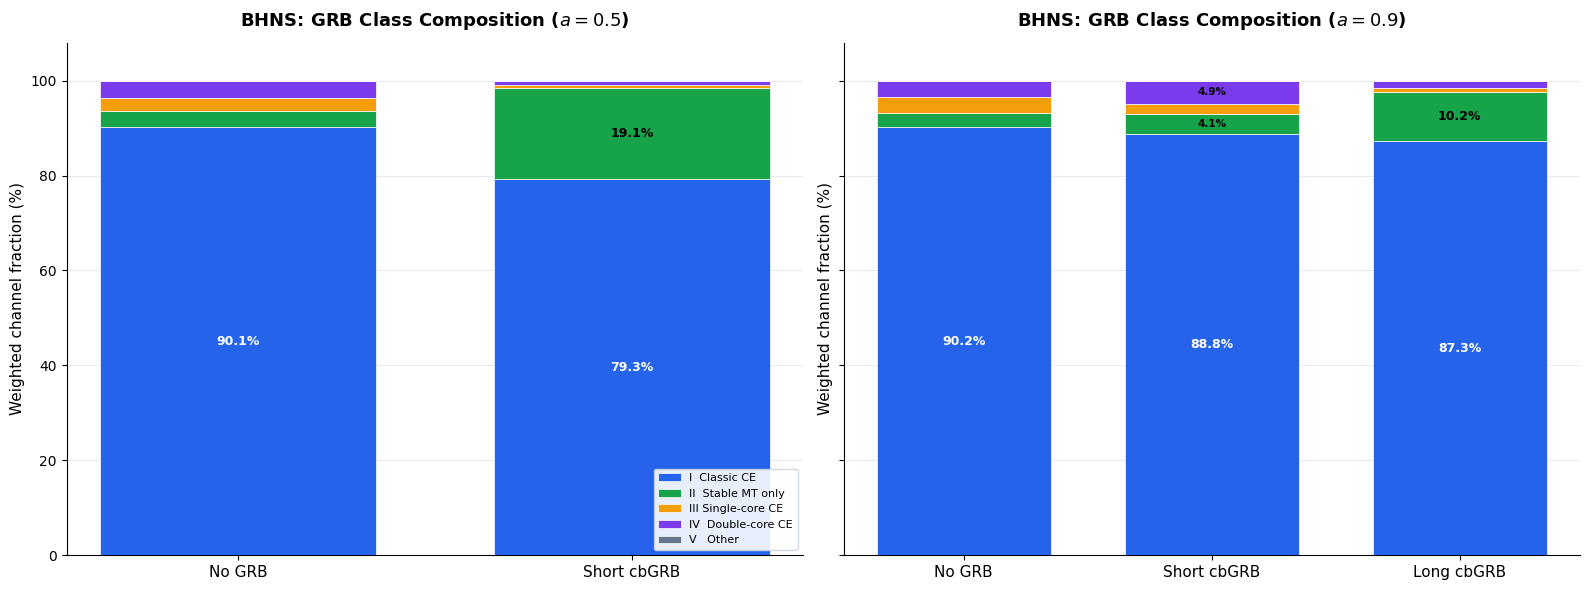

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

ch_colors = {
    'I  Classic CE':      '#2563EB',
    'II  Stable MT only': '#16A34A',
    'III Single-core CE': '#F59E0B',
    'IV  Double-core CE': '#7C3AED',
    'V   Other':          '#64748B',
}

LABEL_THRESH = 4.0
BAR_WIDTH = 0.7

for idx, a_spin in enumerate([0.5, 0.9]):
    ax = axes[idx]
    classes = grb_classes[a_spin]
    grb_names = [n for n in ['No GRB', 'Short cbGRB', 'Long cbGRB'] if classes[n].any()]

    print(f"\n{'='*60}")
    print(f"Cross-tabulation: a_BH = {a_spin}")
    print(f"{'='*60}")
    header = f"{'Channel':<22s}"
    for gn in grb_names:
        header += f"  {gn:>14s}"
    print(header)
    print('-' * (22 + 16 * len(grb_names)))

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color='#E2E8F0', linewidth=0.6, zorder=0)

    bottoms = np.zeros(len(grb_names))
    for ch_name, ch_mask in channel_masks.items():
        fracs = []
        for gn in grb_names:
            grb_mask = classes[gn]
            combined = ch_mask & grb_mask
            w_grb = w_m[grb_mask].sum()
            frac = 100 * w_m[combined].sum() / w_grb if w_grb > 0 else 0.0
            fracs.append(frac)

        row = f"{ch_name:<22s}"
        for f in fracs:
            row += f"  {f:>13.1f}%"
        print(row)

        bars = ax.bar(range(len(grb_names)), fracs, bottom=bottoms, width=BAR_WIDTH,
                       color=ch_colors[ch_name], label=ch_name, edgecolor='white', lw=0.5,
                       zorder=3)

        for j, (frac_val, bar_obj) in enumerate(zip(fracs, bars)):
            if frac_val >= LABEL_THRESH:
                cy = bottoms[j] + frac_val / 2.0
                txt_color = 'white' if ch_name == 'I  Classic CE' else 'black'
                fontsize = 9 if frac_val >= 10 else 7.5
                ax.text(j, cy, f'{frac_val:.1f}%', ha='center', va='center',
                        fontsize=fontsize, fontweight='bold', color=txt_color, zorder=4)

        bottoms += np.array(fracs)

    ax.set_xticks(range(len(grb_names)))
    ax.set_xticklabels(grb_names, fontsize=11, fontweight='medium')
    ax.set_ylabel('Weighted channel fraction (%)', fontsize=11)
    ax.set_title(f'BHNS: GRB Class Composition ($a = {a_spin}$)', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylim(0, 108)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(fontsize=8, loc='lower right', framealpha=0.9, edgecolor='#CBD5E1')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_channel_crosstab.png',
            dpi=200, bbox_inches='tight')
plt.show()

## 5. Mass-Plane Visualization by Formation Channel

Scatter plot of $M_{\rm BH}$ vs $M_{\rm NS}$ colored by formation channel and by GRB class. Uses weighted downsampling for readability.

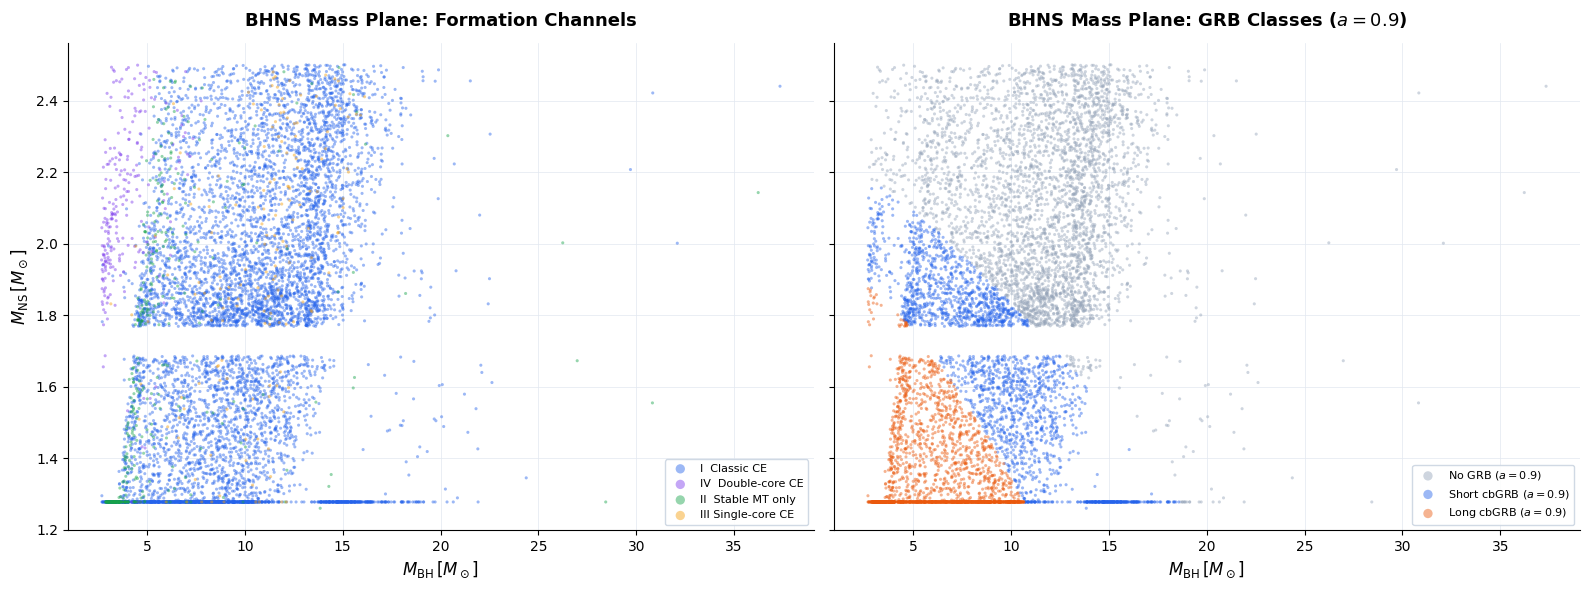

In [12]:
rng = np.random.default_rng(42)

n_sample = min(8000, n_merging)
probs = w_m / w_m.sum()
idx_sample = rng.choice(n_merging, size=n_sample, replace=False, p=probs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

ch_order = ['I  Classic CE', 'IV  Double-core CE', 'II  Stable MT only',
            'III Single-core CE', 'V   Other']

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(True, color='#E2E8F0', linewidth=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax = axes[0]
for ch_name in ch_order:
    ch_mask = channel_masks[ch_name]
    sel = np.intersect1d(idx_sample, np.where(ch_mask)[0])
    if len(sel) > 0:
        ax.scatter(M_BH[sel], M_NS[sel], s=5, alpha=0.45,
                   color=ch_colors[ch_name], label=ch_name, rasterized=True,
                   edgecolors='none', zorder=3)
ax.set_xlabel(r'$M_{\rm BH}\,[M_\odot]$', fontsize=12)
ax.set_ylabel(r'$M_{\rm NS}\,[M_\odot]$', fontsize=12)
ax.set_title('BHNS Mass Plane: Formation Channels', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8, markerscale=3, framealpha=0.9, edgecolor='#CBD5E1',
          loc='lower right')

grb_colors_09 = {'No GRB': '#94A3B8', 'Short cbGRB': '#2563EB', 'Long cbGRB': '#EA580C'}
classes_09 = grb_classes[0.9]

ax = axes[1]
for gn in ['No GRB', 'Short cbGRB', 'Long cbGRB']:
    grb_mask = classes_09[gn]
    sel = np.intersect1d(idx_sample, np.where(grb_mask)[0])
    if len(sel) > 0:
        ax.scatter(M_BH[sel], M_NS[sel], s=5, alpha=0.45,
                   color=grb_colors_09[gn], label=f'{gn} ($a=0.9$)', rasterized=True,
                   edgecolors='none', zorder=3)
ax.set_xlabel(r'$M_{\rm BH}\,[M_\odot]$', fontsize=12)
ax.set_title(r'BHNS Mass Plane: GRB Classes ($a = 0.9$)', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8, markerscale=3, framealpha=0.9, edgecolor='#CBD5E1',
          loc='lower right')

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_mass_plane_channels.png',
            dpi=200, bbox_inches='tight')
plt.show()

## 6. Mass Ratio $Q = M_{\rm BH}/M_{\rm NS}$ Distributions by Formation Channel

The mass ratio $Q$ is the key parameter controlling tidal disruption: higher $Q$ makes disruption harder, requiring higher BH spin. Different formation channels may produce different $Q$ distributions.

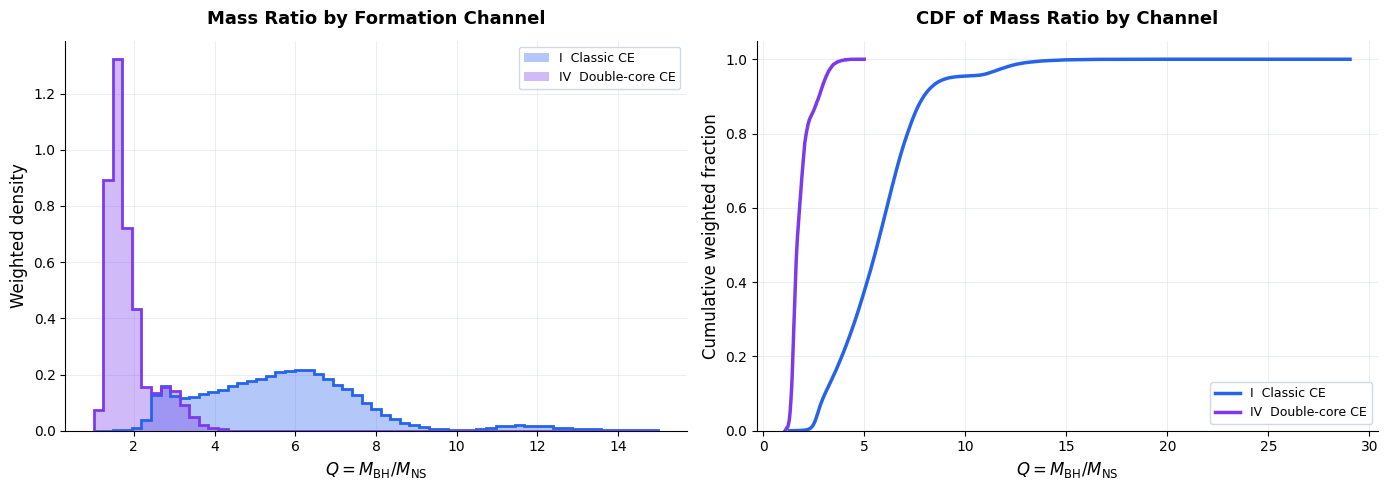

I  Classic CE           weighted mean Q = 5.73  N = 1,500,612
IV  Double-core CE      weighted mean Q = 1.85  N = 9,999
II  Stable MT only      weighted mean Q = 3.63  N = 10,730


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_Q = np.linspace(1, 15, 60)

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(True, color='#E2E8F0', linewidth=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax = axes[0]
for ch_name in ['I  Classic CE', 'IV  Double-core CE']:
    ch_mask = channel_masks[ch_name]
    if ch_mask.any():
        ax.hist(Q[ch_mask], bins=bins_Q, weights=w_m[ch_mask],
                density=True, histtype='stepfilled', lw=1.5,
                color=ch_colors[ch_name], label=ch_name, alpha=0.35, zorder=3)
        ax.hist(Q[ch_mask], bins=bins_Q, weights=w_m[ch_mask],
                density=True, histtype='step', lw=2,
                color=ch_colors[ch_name], zorder=4)
ax.set_xlabel(r'$Q = M_{\rm BH}/M_{\rm NS}$', fontsize=12)
ax.set_ylabel('Weighted density', fontsize=12)
ax.set_title('Mass Ratio by Formation Channel', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#CBD5E1')

ax = axes[1]
for ch_name in ['I  Classic CE', 'IV  Double-core CE']:
    ch_mask = channel_masks[ch_name]
    if ch_mask.any() and ch_mask.sum() > 1:
        vals = Q[ch_mask]
        wts  = w_m[ch_mask]
        order = np.argsort(vals)
        cdf   = np.cumsum(wts[order])
        cdf  /= cdf[-1]
        ax.plot(vals[order], cdf, lw=2.5, color=ch_colors[ch_name], label=ch_name, zorder=3)
ax.set_xlabel(r'$Q = M_{\rm BH}/M_{\rm NS}$', fontsize=12)
ax.set_ylabel('Cumulative weighted fraction', fontsize=12)
ax.set_title('CDF of Mass Ratio by Channel', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9, edgecolor='#CBD5E1')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_Q_by_channel.png',
            dpi=200, bbox_inches='tight')
plt.show()

for ch_name in ['I  Classic CE', 'IV  Double-core CE', 'II  Stable MT only']:
    ch_mask = channel_masks[ch_name]
    if ch_mask.any():
        wmean = np.average(Q[ch_mask], weights=w_m[ch_mask])
        print(f"{ch_name:<22s}  weighted mean Q = {wmean:.2f}  N = {ch_mask.sum():,}")

## 7. Channel Fraction vs Metallicity

Side-by-side comparison: (left) formation channel fractions vs metallicity, (right) GRB class fractions vs metallicity. For BHNS, the formation efficiency drops sharply near solar metallicity due to stronger winds stripping the BH progenitor.

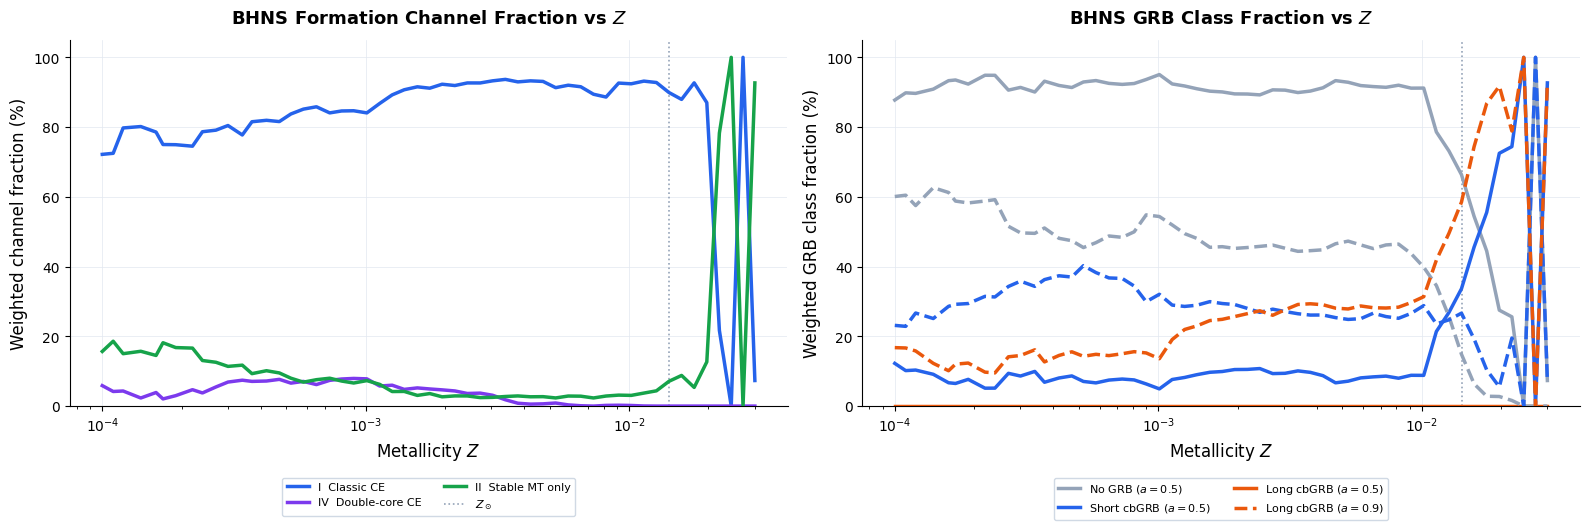

In [16]:
Z_unique = np.sort(np.unique(Z_m))
Z_unique = Z_unique[Z_unique > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(True, color='#E2E8F0', linewidth=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax = axes[0]
for ch_name in ['I  Classic CE', 'IV  Double-core CE', 'II  Stable MT only']:
    ch_mask = channel_masks[ch_name]
    fracs = []
    for z_val in Z_unique:
        z_mask = (Z_m == z_val)
        w_z = w_m[z_mask].sum()
        frac = w_m[z_mask & ch_mask].sum() / w_z if w_z > 0 else 0
        fracs.append(frac * 100)
    ax.plot(Z_unique, fracs, lw=2.5, color=ch_colors[ch_name], label=ch_name, zorder=3)

ax.axvline(0.0142, color='#94A3B8', ls=':', lw=1.2, zorder=2, label=r'$Z_\odot$')

ax.set_xscale('log')
ax.set_xlabel(r'Metallicity $Z$', fontsize=12)
ax.set_ylabel('Weighted channel fraction (%)', fontsize=12)
ax.set_title(r'BHNS Formation Channel Fraction vs $Z$', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8, framealpha=0.9, edgecolor='#CBD5E1',
          bbox_to_anchor=(0.5, -0.18), loc='upper center', ncol=2)
ax.set_ylim(0, 105)

grb_line_colors = {'No GRB': '#94A3B8', 'Short cbGRB': '#2563EB', 'Long cbGRB': '#EA580C'}

ax = axes[1]
for a_spin in [0.5, 0.9]:
    classes = grb_classes[a_spin]
    ls = '-' if a_spin == 0.5 else '--'
    for gn in ['No GRB', 'Short cbGRB', 'Long cbGRB']:
        grb_mask = classes[gn]
        fracs = []
        for z_val in Z_unique:
            z_mask = (Z_m == z_val)
            w_z = w_m[z_mask].sum()
            frac = w_m[z_mask & grb_mask].sum() / w_z if w_z > 0 else 0
            fracs.append(frac * 100)
        label = f'{gn} ($a={a_spin}$)' if a_spin == 0.5 or gn == 'Long cbGRB' else None
        ax.plot(Z_unique, fracs, lw=2.5, color=grb_line_colors[gn], ls=ls, label=label, zorder=3)

ax.axvline(0.0142, color='#94A3B8', ls=':', lw=1.2, zorder=2)

ax.set_xscale('log')
ax.set_xlabel(r'Metallicity $Z$', fontsize=12)
ax.set_ylabel('Weighted GRB class fraction (%)', fontsize=12)
ax.set_title(r'BHNS GRB Class Fraction vs $Z$', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8, framealpha=0.9, edgecolor='#CBD5E1',
          bbox_to_anchor=(0.5, -0.18), loc='upper center', ncol=2)
ax.set_ylim(0, 105)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_channel_vs_Z.png',
            dpi=200, bbox_inches='tight')
plt.show()

## 8. Channel-Resolved Cosmic Merger Rates

Using the Neijssel et al. (2019) MSSFR model to compute $\mathcal{R}(z)$ for each formation channel crossed with GRB class. The `compute_merger_rate` function is identical to `GRB_BNS_FormationChannels.ipynb` and `GRB_CosmicRate.ipynb`.

In [8]:
sys.path.insert(0, '/Users/josephrodriguez/research visualization/COMPAS')
from compas_python_utils.cosmic_integration.FastCosmicIntegration import (
    calculate_redshift_related_params,
    find_sfr,
    find_metallicity_distribution,
)

redshifts, n_z_detect, times, time_first_SF, distances, shell_volumes = \
    calculate_redshift_related_params(max_redshift=10.0, redshift_step=0.01)
sfr     = find_sfr(redshifts)
dPdlogZ, metallicities, p_draw = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=np.log(0.0001),
    max_logZ_COMPAS=np.log(0.03),
)

def compute_merger_rate(redshifts, times, time_first_SF, n_formed,
                        dPdlogZ, metallicities, p_draw,
                        COMPAS_Z, COMPAS_delay_times, COMPAS_weights):
    n_z           = len(redshifts)
    redshift_step = redshifts[1] - redshifts[0]
    times_to_z    = interp1d(times, redshifts)
    Z_bins = np.clip(np.digitize(COMPAS_Z, metallicities), 0, len(metallicities) - 1)
    t_min = max(time_first_SF, times.min())
    total_merger = np.zeros(n_z)
    for i in range(len(COMPAS_delay_times)):
        form_i = n_formed * dPdlogZ[:, Z_bins[i]] / p_draw * COMPAS_weights[i]
        t_form = times - COMPAS_delay_times[i]
        valid = (t_form >= t_min)
        if not valid.any():
            continue
        j_idx      = np.where(valid)[0]
        z_form     = times_to_z(t_form[j_idx])
        z_form_idx = np.clip(np.ceil(z_form / redshift_step).astype(int), 0, n_z - 1)
        total_merger[j_idx] += form_i[z_form_idx]
    return total_merger

meanMassEvolved = 77708655
n_formed = sfr / meanMassEvolved
print(f"Cosmological grid ready: {len(redshifts)} redshift bins")

Cosmological grid ready: 1001 redshift bins


a=0.5 | All BHNS | all                                 : z=0 2246.6 Gpc^-3 yr^-1
a=0.5 | All BHNS | I  Classic CE                       : z=0 1980.1 Gpc^-3 yr^-1
a=0.5 | All BHNS | IV  Double-core CE                  : z=0 11.5 Gpc^-3 yr^-1
a=0.5 | Short cbGRB | all                              : z=0 397.8 Gpc^-3 yr^-1
a=0.5 | Short cbGRB | I  Classic CE                    : z=0 308.2 Gpc^-3 yr^-1
a=0.5 | Short cbGRB | IV  Double-core CE               : z=0 0.1 Gpc^-3 yr^-1
a=0.9 | All BHNS | all                                 : z=0 2246.6 Gpc^-3 yr^-1
a=0.9 | All BHNS | I  Classic CE                       : z=0 1980.1 Gpc^-3 yr^-1
a=0.9 | All BHNS | IV  Double-core CE                  : z=0 11.5 Gpc^-3 yr^-1
a=0.9 | Short cbGRB | all                              : z=0 717.6 Gpc^-3 yr^-1
a=0.9 | Short cbGRB | I  Classic CE                    : z=0 636.6 Gpc^-3 yr^-1
a=0.9 | Short cbGRB | IV  Double-core CE               : z=0 7.0 Gpc^-3 yr^-1
a=0.9 | Long cbGRB | all                  

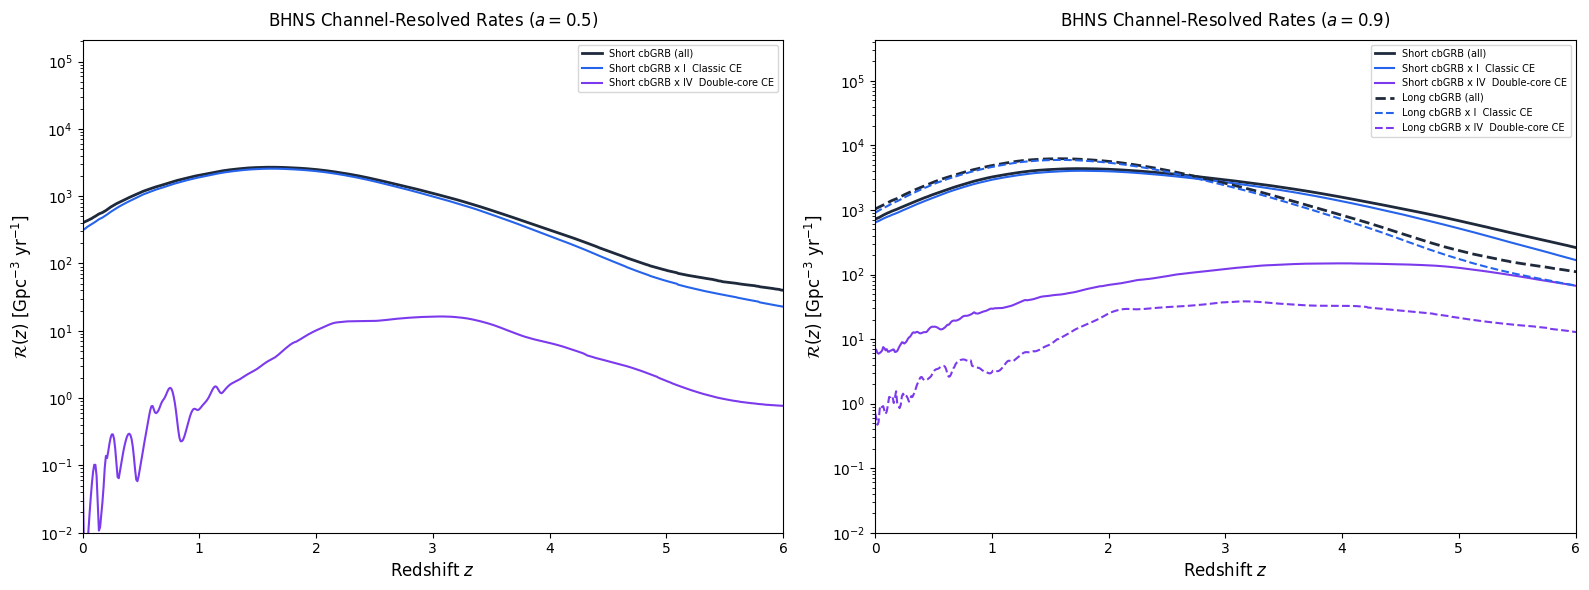

In [10]:
rate_results = {}

for a_spin in [0.5, 0.9]:
    classes = grb_classes[a_spin]

    combos = [('All BHNS', np.ones(n_merging, dtype=bool))]
    for gn in ['Short cbGRB', 'Long cbGRB']:
        if classes[gn].any():
            combos.append((gn, classes[gn]))

    ch_subset = [
        ('I  Classic CE', ch_I),
        ('IV  Double-core CE', ch_IV),
    ]

    for grb_label, grb_mask in combos:
        key = f"a={a_spin} | {grb_label} | all"
        rate_results[key] = compute_merger_rate(
            redshifts, times, time_first_SF, n_formed,
            dPdlogZ, metallicities, p_draw,
            Z_m[grb_mask], delay_m[grb_mask], w_m[grb_mask])
        print(f"{key:<55s}: z=0 {rate_results[key][0]:.1f} Gpc^-3 yr^-1")

        for ch_label, ch_mask in ch_subset:
            combined = grb_mask & ch_mask
            if combined.any():
                key2 = f"a={a_spin} | {grb_label} | {ch_label}"
                rate_results[key2] = compute_merger_rate(
                    redshifts, times, time_first_SF, n_formed,
                    dPdlogZ, metallicities, p_draw,
                    Z_m[combined], delay_m[combined], w_m[combined])
                print(f"{key2:<55s}: z=0 {rate_results[key2][0]:.1f} Gpc^-3 yr^-1")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rate_colors = {'all': '#1E293B', 'I  Classic CE': '#2563EB', 'IV  Double-core CE': '#7C3AED'}

for idx, a_spin in enumerate([0.5, 0.9]):
    ax = axes[idx]
    grb_labels = ['Short cbGRB']
    if a_spin == 0.9:
        grb_labels.append('Long cbGRB')

    for grb_label in grb_labels:
        ls = '-' if grb_label == 'Short cbGRB' else '--'
        key_all = f"a={a_spin} | {grb_label} | all"
        if key_all in rate_results:
            ax.semilogy(redshifts, rate_results[key_all], lw=2, ls=ls,
                        color=rate_colors['all'], label=f'{grb_label} (all)')

        for ch_label in ['I  Classic CE', 'IV  Double-core CE']:
            key_ch = f"a={a_spin} | {grb_label} | {ch_label}"
            if key_ch in rate_results:
                ax.semilogy(redshifts, rate_results[key_ch], lw=1.5, ls=ls,
                            color=rate_colors[ch_label], label=f'{grb_label} x {ch_label}')

    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.set_ylabel(r'$\mathcal{R}(z)$ [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
    ax.set_title(f'BHNS Channel-Resolved Rates ($a = {a_spin}$)', fontsize=12, pad=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(0, 6)
    ax.set_ylim(bottom=1e-2)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bhns_channel_rates.png',
            dpi=200, bbox_inches='tight')
plt.show()

## 9. Unified BNS vs BHNS Comparison

This section completes the commenter's unified evolutionary picture by contrasting the BNS and BHNS formation channel results.

### Channel Composition Summary

| Property | BNS | BHNS |
|---|---|---|
| **Dominant formation channel** | Double-core CE (~75% STROOPWAFEL-weighted, COMPAS Model A) | Classic CE (~85%+ weighted) |
| **Long cbGRB channel origin** | Classic CE (asymmetric masses) | Classic CE (all channels, spin-dependent) |
| **Channel diversity in GRB classes** | Yes: Short = mixed, Long = Classic CE enriched | No: Classic CE dominates all classes |
| **Metallicity sensitivity** | Weak (NS progenitors have low winds) | Strong (BH progenitors stripped at high Z) |
| **Double-core CE role** | Dominant: produces equal-mass NS pairs | Negligible (~1%): near-equal masses rarely produce BH+NS |

### Physical Interpretation

**Classic CE as the unifying evolutionary pathway:** The Classic CE channel is the thread connecting both populations:

1. **For BNS:** Classic CE produces the *asymmetric* mass pairs (via different SN mechanisms for each NS) that cross the $q \geq 1.2$ threshold into Long cbGRB territory. While Double-core CE dominates the BNS population overall, it produces *symmetric* masses that stay in Short cbGRB territory.

2. **For BHNS:** Classic CE dominates the *entire* population because the initial mass asymmetry required to produce a BH+NS pair (rather than BNS or BBH) naturally selects against Double-core CE (which requires $q_i \sim 0.9$-$1.0$).

3. **The unified picture:** Mass asymmetry is the key. Classic CE *creates* asymmetry (different SN mechanisms for each component), while Double-core CE *eliminates* it (similar progenitors undergo similar evolution). For BNS, this asymmetry determines the GRB class. For BHNS, the asymmetry is built into the population by construction.

This explains why Broekgaarden et al. (2021, Paper I) found ~86% Classic CE for BHNS but only ~25% for BNS (STROOPWAFEL-weighted, COMPAS Model A): the initial mass ratio requirements for forming a BH+NS pair are fundamentally incompatible with the Double-core CE pathway.

## 10. Summary & Discussion

### Key Results

1. **Classic CE dominates BHNS formation:** The Classic CE channel (Channel I) accounts for ~85%+ of all merging BHNS systems (weighted), with Double-core CE (Channel IV) negligible at ~1%. This confirms Broekgaarden et al. (2021, Paper I).

2. **All BHNS GRB classes are Classic CE dominated:** At both $a = 0.5$ and $a = 0.9$, Classic CE accounts for the overwhelming majority of GRB-producing systems. There is no channel diversity across GRB classes, unlike BNS.

3. **BHNS formation efficiency is strongly metallicity-dependent:** The Classic CE fraction is high across all metallicities, but total BHNS formation drops sharply near solar $Z$ due to wind-driven mass loss from the BH progenitor.

4. **Classic CE is the unifying channel:** It produces the asymmetric BNS mergers that yield Long cbGRBs *and* dominates the entire BHNS population. Double-core CE creates symmetric systems: equal-mass BNS (Short cbGRBs) and essentially no BHNS.

### Caveats

- **Fiducial model only:** All results use COMPAS Model A. Channel fractions are sensitive to common envelope efficiency ($\alpha_{\rm CE}$), mass transfer stability criteria, natal kick prescriptions, and Hertzsprung-gap CE survival. The Broekgaarden et al. (2022) 560-model grid shows significant variation.
- **Channel proxy uncertainty:** Channels I-III are identified from proxy flags (`SemiMajorAxisPreCEE`, `PrimaryMTCase`), not the definitive `formationChannels` HDF5 group. The Channel III proxy (`PrimaryMTCase == 0`) should be verified against COMPAS documentation.
- **BH spin not tracked:** All BHNS GRB classifications are conditional on assumed $a_{\rm BH}$. Fuller & Ma (2019, ApJL 881, L1) predict low natal spins ($a \sim 0$-$0.1$) for isolated BHs, which would eliminate the BHNS GRB channel entirely.
- **Sigmoid $f_{\rm disk}$ simplification:** The remnant-to-disk conversion is a custom sigmoid, not from a published NR calibration. See `GRB_BHNS.ipynb` Section 14 for $f_{\rm disk}$ sensitivity analysis.
- **Isolated binary evolution only:** No dynamical channels (globular clusters, AGN disks) are considered.
- **Rapid population synthesis:** COMPAS uses the Hurley et al. (2000) fitting formulae for stellar evolution, which have known limitations for massive stars and binary interactions.

### Future Directions

- **Multi-model robustness:** Run formation channel analysis across multiple COMPAS models (varying $\alpha_{\rm CE}$, kicks, etc.) to test whether the Classic CE dominance for BHNS is robust.
- **Definitive channel labels:** Use the `formationChannels` HDF5 group for event-sequence-based classification instead of proxies.
- **BH spin distribution models:** Apply physically motivated spin distributions (e.g., Fuller & Ma 2019) to compute spin-marginalized BHNS channel fractions.
- **Compare with the BNS formation channel analysis** in `GRB_BNS_FormationChannels.ipynb` to quantify the Classic CE fraction across both populations as a function of metallicity and redshift.